# Dependencies


In [1]:
# pip install ultralytics opencv-python matplotlib pandas scikit-image --no-cache

# Libraries

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [3]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
# pip uninstall torch torchvision torchaudio -y

In [5]:
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128 --no-cache

In [6]:
# import torch
# print(torch.__version__)
# print(torch.cuda.is_available())
# print(torch.cuda.get_device_name(0))

# Google Drive for Dataset and Research

In [7]:
# from google.colab import drive

# drive.mount('/content/drive')

# Create dataset.yaml

In [8]:
print(os.getcwd())

yaml_content = """
path: dataset

train: images/train
val: images/val

names:
  0: droplet
"""

# with open('/content/drive/MyDrive/Project/DropletDetection/dataset/dataset.yaml', 'w') as f:
#     f.write(yaml_content)
with open('dataset/dataset.yaml', 'w') as f:
    f.write(yaml_content)

print('dataset.yaml created successfully')

## Verify Dataset
# train_path = '/content/drive/MyDrive/Project/DropletDetection/dataset/images/train'
train_path = 'dataset/images/train'

print('Training Images:', len(os.listdir(train_path)))

/home/adli-ubuntu/Documents/Project/DropletDetection
dataset.yaml created successfully
Training Images: 250


## Sample Image

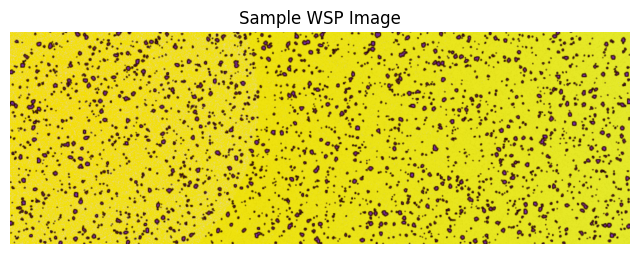

In [9]:
sample_image = os.path.join(train_path, os.listdir(train_path)[0])

image = cv2.imread(sample_image)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.title('Sample WSP Image')
plt.axis('off')
plt.show()

## OpenCV Preprocessing

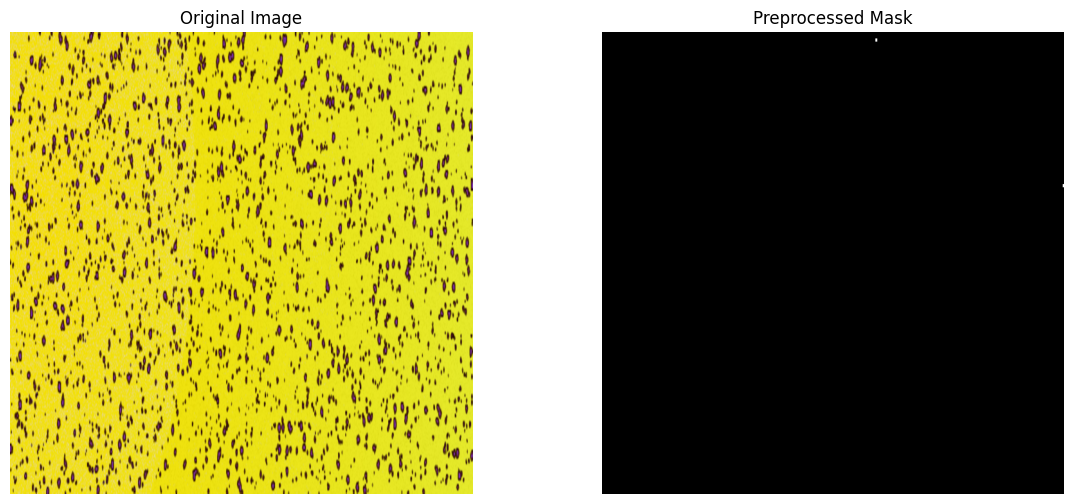

In [10]:
## Preprocessing Function
def preprocess_wsp(image_path):

    image = cv2.imread(image_path)

    # Resize optional
    image = cv2.resize(image, (720, 720))

    # Convert to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Blue droplet threshold
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([140, 255, 255])

    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Median blur
    mask = cv2.medianBlur(mask, 3)

    # Morphology cleanup
    kernel = np.ones((3,3), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return image, mask

## Testing Function
image, mask = preprocess_wsp(sample_image)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title('Preprocessed Mask')
plt.axis('off')

plt.show()

# YOLO

## Load YOLOv8 Segmentation Model

In [11]:
model = YOLO('yolov8n-seg.pt') ## Fast
# model = YOLO('yolov8s-seg.pt') ## Recommend

ConnectionError: ❌  Download failure for https://github.com/ultralytics/assets/releases/download/v8.4.0/yolov8n-seg.pt. Environment may be offline.

## Train and Validate Model

In [ ]:
results = model.train(
    data='dataset/dataset.yaml',
    
    epochs=30,
    batch=2,
    
    imgsz=720,
    
    optimizer='AdamW',
    
    # lr0=0.001,
    overlap_mask=True,
    
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    amp=True,
    cache=False,
    workers=2,
    patience=10,
    
    project="YOLOv8/wsp_yolov8_seg",
    name="WSP_YoloV8_Seg"
)

metrics = model.val()

print(metrics)

Ultralytics 8.4.50 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=720, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=WSP_YoloV8_Seg-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, ov

## Runnging Prediciton

In [ ]:
best_model = YOLO(
    # "/content/drive/MyDrive/Project/DropletDetection/wsp_yolov8_seg/weights/best.pt"
    "YOLOv8/wsp_yolov8_seg/weights/best.pt"
    # "runs/segment/train-4/weights/best.pt"
) ## Load best model

results = best_model.predict(
    source=sample_image,
    conf=0.25,
    save=True
) ## Run prediction

pred_image = results[0].plot()  ## Plot prediction

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(pred_image, cv2.COLOR_BGR2RGB))
plt.title('YOLOv8-seg Prediction')
plt.axis('off')
plt.show()

# Coverage Estimation

In [ ]:
masks = results[0].masks.data.cpu().numpy()

combined_mask = np.any(masks, axis=0)

binary_mask = combined_mask.astype(np.uint8)*255

droplet_pixels = np.sum(binary_mask == 255)

total_pixels = binary_mask.size

coverage = (droplet_pixels / total_pixels) * 100

print(f'Coverage Percentage: {coverage:.2f}%')

# Droplet Counting

In [ ]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask)

# Remove background label
actual_droplets = num_labels - 1

print('Droplet Count:', actual_droplets)

# Export Result

In [ ]:
# results_df = pd.DataFrame({
#     'coverage_percent': [coverage],
#     'droplet_count': [actual_droplets],
#     'mean_diameter_pixels': [mean_diameter]
# })

# csv_path = '/content/drive/MyDrive/Project/DropletDetection/DD_Training/results.csv'

# results_df.to_csv(csv_path, index=False)

# print('Results exported to:', csv_path)

# Save Binary Mask

In [ ]:
# mask_path = '/content/drive/MyDrive/Project/DropletDetection/DD_Training/binary_mask.png'

# cv2.imwrite(mask_path, binary_mask)

# print('Mask saved to:', mask_path)

# Batch Processing

In [ ]:
# input_folder = '/content/drive/MyDrive/WSP_Dataset/images/test'

# all_results = []

# for filename in os.listdir(input_folder):

#     image_path = os.path.join(input_folder, filename)

#     results = best_model.predict(image_path, conf=0.25)

#     masks = results[0].masks.data.cpu().numpy()

#     combined_mask = np.any(masks, axis=0)

#     binary_mask = combined_mask.astype(np.uint8) * 255

#     droplet_pixels = np.sum(binary_mask == 255)

#     total_pixels = binary_mask.size

#     coverage = (droplet_pixels / total_pixels) * 100

#     num_labels, labels = cv2.connectedComponents(binary_mask)

#     droplet_count = num_labels - 1

#     all_results.append({
#         'image': filename,
#         'coverage_percent': coverage,
#         'droplet_count': droplet_count
#     })

# batch_df = pd.DataFrame(all_results)

# batch_csv = '/content/drive/MyDrive/WSP_Training/batch_results.csv'

# batch_df.to_csv(batch_csv, index=False)

# print('Batch processing completed')